In [12]:
# pip install polars
# !pip install matplotlib
# !pip install pandas
# !pip install seaborn
# import polars as pl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Polars

In [57]:
def read_txt(filepath):
    with open(filepath, "r") as file:
        data = [line.strip().split() for line in file]
    df = pl.DataFrame(data[1:], schema={col: float for col in data[0]}, orient="row")
    return df

In [58]:
# gmres_1
gmres_1_richardson = read_txt(filepath="../data/models/mixed_srpde/unit_square_coarse/gmres_1/output/richardson_gen.txt")

In [59]:
# iterative_1
iterative_1_richardson = read_txt(filepath="../data/models/mixed_srpde/unit_square_coarse/iterative_1/output/richardson_gen.txt")

In [62]:
iterative_1_richardson

time_init,time_solve,time,rmse_f,rmse_beta,rmse_alpha,n_obs,m,rmse_f_1,rmse_f_2,rmse_f_3,rmse_f_4,rmse_f_5,rmse_f_6,rmse_f_7,rmse_f_8,rmse_f_9,rmse_f_10,rmse_f_11,rmse_f_12,rmse_f_13,rmse_f_14,rmse_f_15,rmse_f_16,rmse_f_17,rmse_f_18,rmse_f_19,rmse_f_20,rmse_f_21,rmse_f_22,rmse_f_23,rmse_f_24,rmse_f_25
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0252743,0.0411081,0.0663824,0.0190932,0.0304922,0.0643227,500.0,5.0,0.0357379,0.000887,0.030786,0.002838,0.0252172,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.01919,0.0405745,0.0597645,0.006731,0.0221177,0.0485152,500.0,5.0,0.0168828,0.001056,0.001176,0.0132857,0.001256,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0199326,0.0462564,0.066189,0.0118187,0.0208226,0.0553956,500.0,5.0,0.0343742,0.000951,0.00923,0.007232,0.007306,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0212495,0.0522359,0.0734854,0.0324527,0.0218488,0.0851463,500.0,5.0,0.023678,0.003016,0.0039287,0.126032,0.005609,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0245573,0.0497217,0.074279,0.008197,0.0222799,0.0497037,500.0,5.0,0.0159418,0.0067,0.001549,0.0159026,0.000892,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.429947,0.200021,0.629968,0.001504,0.003897,0.003572,8000.0,25.0,0.001957,0.000418,0.000695,0.005482,0.000599,0.000699,0.000599,0.000699,0.00014,0.000221,0.00014,0.000699,0.000221,0.00039,0.005482,0.000599,0.000699,0.000699,0.005482,0.000221,0.005482,0.000181,0.000181,0.005482,0.00014
0.507511,0.18643,0.693941,0.008117,0.004039,0.0132626,8000.0,25.0,0.003346,0.001521,0.001528,0.0324898,0.001665,0.001473,0.001665,0.001473,0.002734,0.002264,0.002734,0.001473,0.002264,0.001744,0.0324898,0.001665,0.001473,0.001473,0.0324898,0.002264,0.0324898,0.002493,0.002493,0.0324898,0.002734
0.43444,0.161196,0.595636,0.003541,0.004079,0.006529,8000.0,25.0,0.0115949,0.000568,0.000077,0.0119304,0.000069,0.000067,0.000069,0.000067,0.002682,0.000775,0.002682,0.000067,0.000775,0.000612,0.0119304,0.000069,0.000067,0.000067,0.0119304,0.000775,0.0119304,0.002555,0.002555,0.0119304,0.002682


In [205]:
def compare_iterative_gmres(data, n_obs_fix, n_lvl_fix):
    
    fixed_obs = data.query(f"n_obs == {n_obs_fix}")
    fixed_lvl = data.query(f"m == {n_lvl_fix}")

    # time vs number of obs
    plt.figure(figsize=(12,8))
    plt.subplot(2,3,1)
    sns.boxplot(x='n_obs', y='time', hue='method', data=fixed_lvl, palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Duration wrt number of observations \n(n_levels = {n_lvl_fix})")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel('Duration [s]')

    # time vs number of levels
    plt.subplot(2,3,4)
    sns.boxplot(x='m', y='time', hue='method', data=fixed_obs, palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Duration wrt number of levels \n(n_obs={n_obs_fix})")
    plt.legend(title='Method')
    plt.xlabel('Number of levels')
    plt.ylabel('Duration [s]')

    # RMSE vs number of obs
    plt.subplot(2,3,2)
    sns.boxplot(x='n_obs', y='rmse_f', hue='method', data=fixed_lvl, palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"RMSE f wrt number of observations \n(n_levels = {n_lvl_fix})")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel('RMSE on f')

    # RMSE vs number of levels
    plt.subplot(2,3,5)
    sns.boxplot(x='m', y='rmse_f', hue='method', data=fixed_obs, palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"RMSE f wrt number of levels \n(n_obs={n_obs_fix})")
    plt.legend(title='Method')
    plt.xlabel('Number of levels')
    plt.ylabel('RMSE on f')

    # beta RMSE vs number of obs
    plt.subplot(2,3,3)
    sns.boxplot(x='n_obs', y='rmse_beta', hue='method', data=fixed_lvl, palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"RMSE beta wrt number of observations \n(n_levels = {n_lvl_fix})")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel('RMSE on beta')

    # beta RMSE vs number of levels
    plt.subplot(2,3,6)
    sns.boxplot(x='m', y='rmse_beta', hue='method', data=fixed_obs, palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"RMSE beta wrt number of levels \n(n_obs={n_obs_fix})")
    plt.legend(title='Method')
    plt.xlabel('Number of levels')
    plt.ylabel('RMSE on beta')
    plt.tight_layout()
    plt.show()

# Confronto iterativo - GMRES: caso base

Comparison iterative vs GMRES (memory = 3)


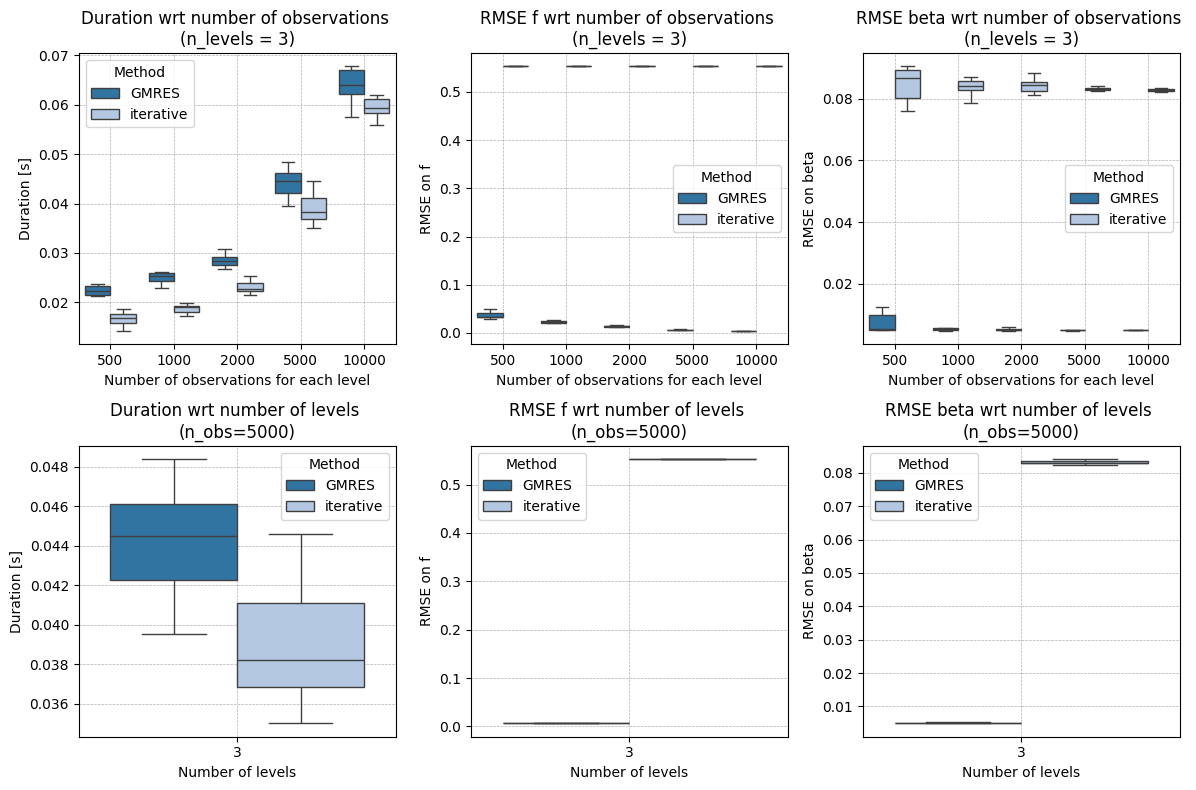

In [ ]:
gmres_1_richardson = pd.read_csv("../data/models/mixed_srpde/unit_square/gmres_base_case/output/richardson_gen.txt", sep=" ")
iterative_1_richardson = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/iterative_base_case/output/richardson_gen.txt", sep=" ")
gmres_1_richardson = gmres_1_richardson.assign(method='GMRES')
iterative_1_richardson = iterative_1_richardson.assign(method='iterative')
data = pd.DataFrame(pd.concat([gmres_1_richardson,iterative_1_richardson]))

n_obs_fix = 5000
n_lvl_fix = 3

print(f"Comparison iterative vs GMRES (memory = 3)")
compare_iterative_gmres(data=data, n_obs_fix=n_obs_fix, n_lvl_fix=n_lvl_fix)

# Mesh comparison

$\beta = [-2; 1]$

$\alpha = [-0.5, 0, 0.5]$

$m=3$

$n\_obs = [500, 1000, 2000, 5000, 10000]$

same locations

$\lambda = 1$

$mem = 0$ (no GMRES)

In [ ]:
usc_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square")
usc_rich = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_usc/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square")

usm_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_medium")
usm_rich = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_medium")

usf_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_fine/mesh_usf/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_fine")
usf_rich = pd.read_csv("../data/models/mixed_srpde/unit_square_fine/mesh_usf/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_fine")

In [323]:
data = pd.DataFrame(pd.concat([usc_mono, usc_rich, usm_mono, usm_rich, usf_mono, usf_rich]))
mono = pd.DataFrame(pd.concat([usc_mono, usm_mono, usf_mono]))
rich = pd.DataFrame(pd.concat([usc_rich, usm_rich, usf_rich]))

In [266]:
data

,time_init,time_solve,time,rmse_f,rmse_beta,rmse_alpha,n_obs,m,rmse_f_1,rmse_f_2,rmse_f_3,policyID,mesh
0,0.015178,0.001708,0.016887,0.036916,0.007603,0.009660,500,3,0.097372,0.002694,0.010683,monolithic,unit_square_coarse
1,0.014955,0.001640,0.016594,0.033404,0.005535,0.005535,500,3,0.087302,0.003151,0.009761,monolithic,unit_square_coarse
2,0.014492,0.001705,0.016197,0.046005,0.007049,0.019147,500,3,0.124752,0.003021,0.010241,monolithic,unit_square_coarse
3,0.016169,0.001864,0.018033,0.031586,0.006638,0.002778,500,3,0.082731,0.002500,0.009526,monolithic,unit_square_coarse
4,0.017558,0.001867,0.019425,0.031558,0.006418,0.004485,500,3,0.083470,0.001885,0.009320,monolithic,unit_square_coarse
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,2.647030,3.378060,6.025100,0.002770,0.005092,0.000721,10000,3,0.007663,0.000171,0.000477,richardson,unit_square_fine
46,1.549040,4.406690,5.955720,0.002272,0.004927,0.000205,10000,3,0.005988,0.000270,0.000558,richardson,unit_square_fine
47,2.310120,6.671880,8.982000,0.002703,0.005187,0.000479,10000,3,0.007178,0.000231,0.000700,richardson,unit_square_fine
48,1.670790,5.394360,7.065160,0.002111,0.004996,0.000001,10000,3,0.005623,0.000218,0.000492,richardson,unit_square_fine


Text(0, 0.5, 'Time')

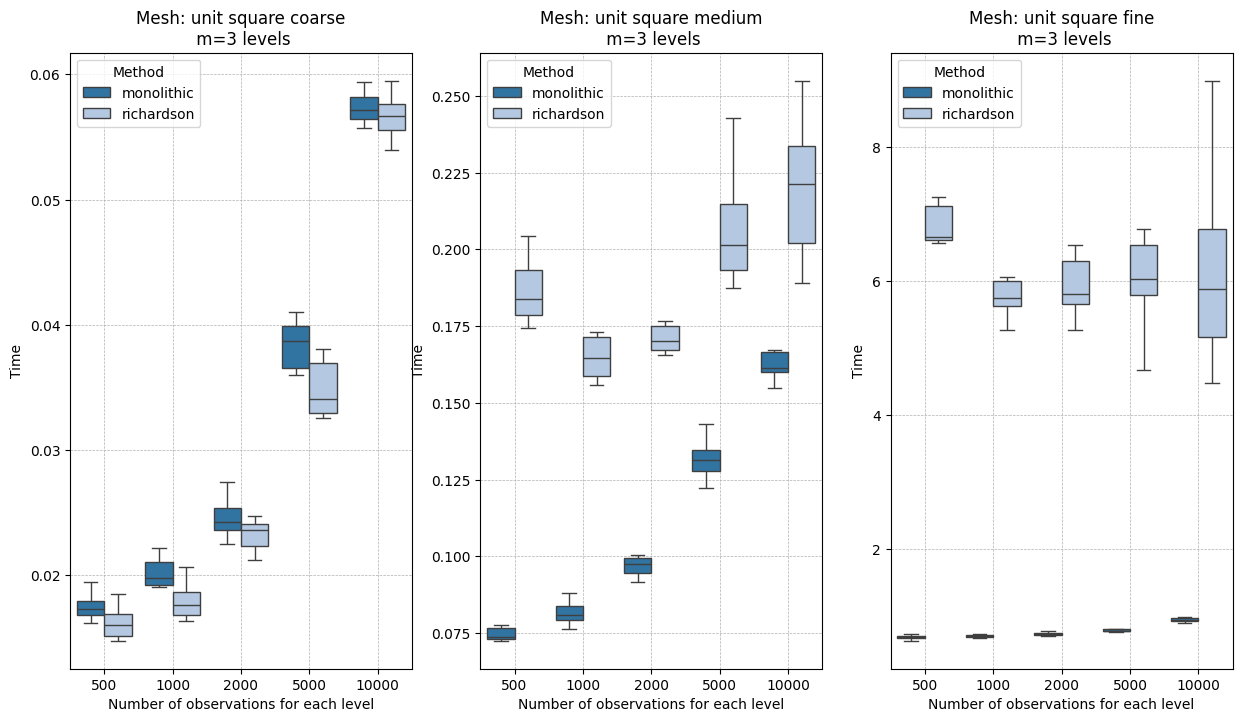

In [ ]:
# mono vs rich
plt.figure(figsize=(15,8))
plt.subplot(1,3,1)
sns.boxplot(x='n_obs', y='time', hue='policyID', data=data.query("mesh=='unit_square_coarse'"), palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square coarse/n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Time')
plt.subplot(1,3,2)
sns.boxplot(x='n_obs', y='time', hue='policyID', data=data.query("mesh=='unit_square_medium'"), palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square medium/n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Time')
plt.subplot(1,3,3)
sns.boxplot(x='n_obs', y='time', hue='policyID', data=data.query("mesh=='unit_square_fine'"), palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square fine/n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Time')

Text(0, 0.5, 'RMSE f')

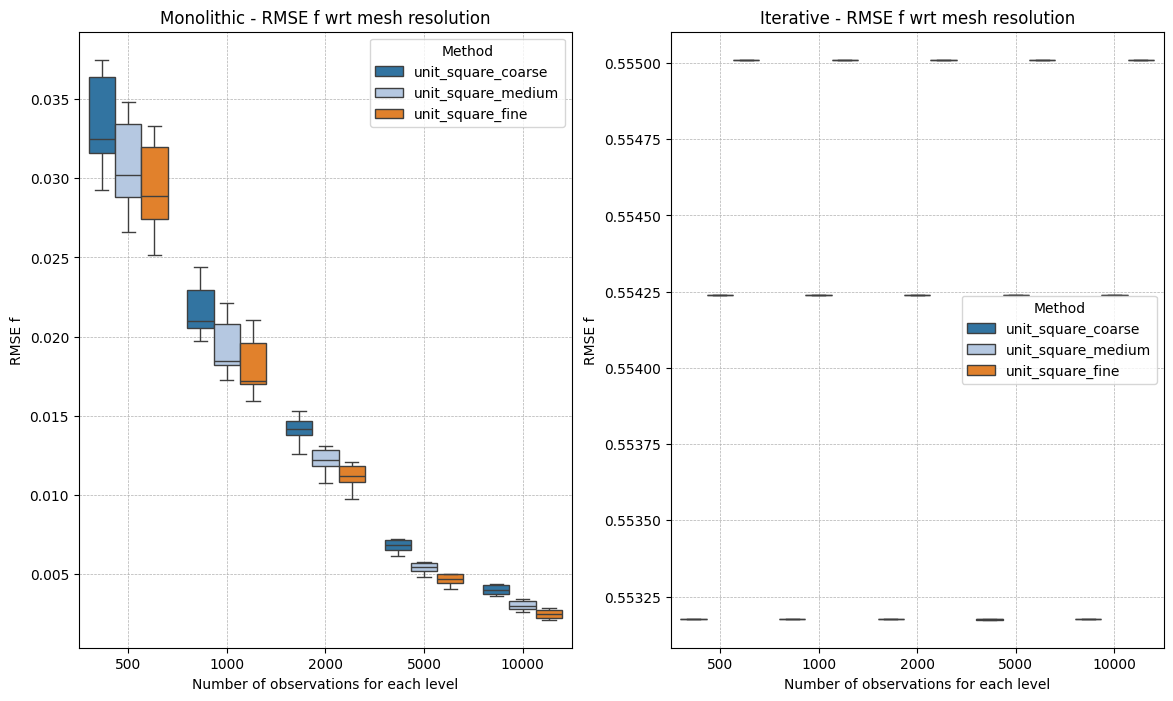

In [ ]:
# RMSE vs mesh
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
sns.boxplot(x='n_obs', y='rmse_f', hue='mesh', data=mono, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Monolithic - RMSE f wrt mesh resolution")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('RMSE f')
plt.subplot(1,2,2)
sns.boxplot(x='n_obs', y='rmse_f', hue='mesh', data=rich, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Iterative - RMSE f wrt mesh resolution")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('RMSE f')

Text(0, 0.5, 'RMSE f')

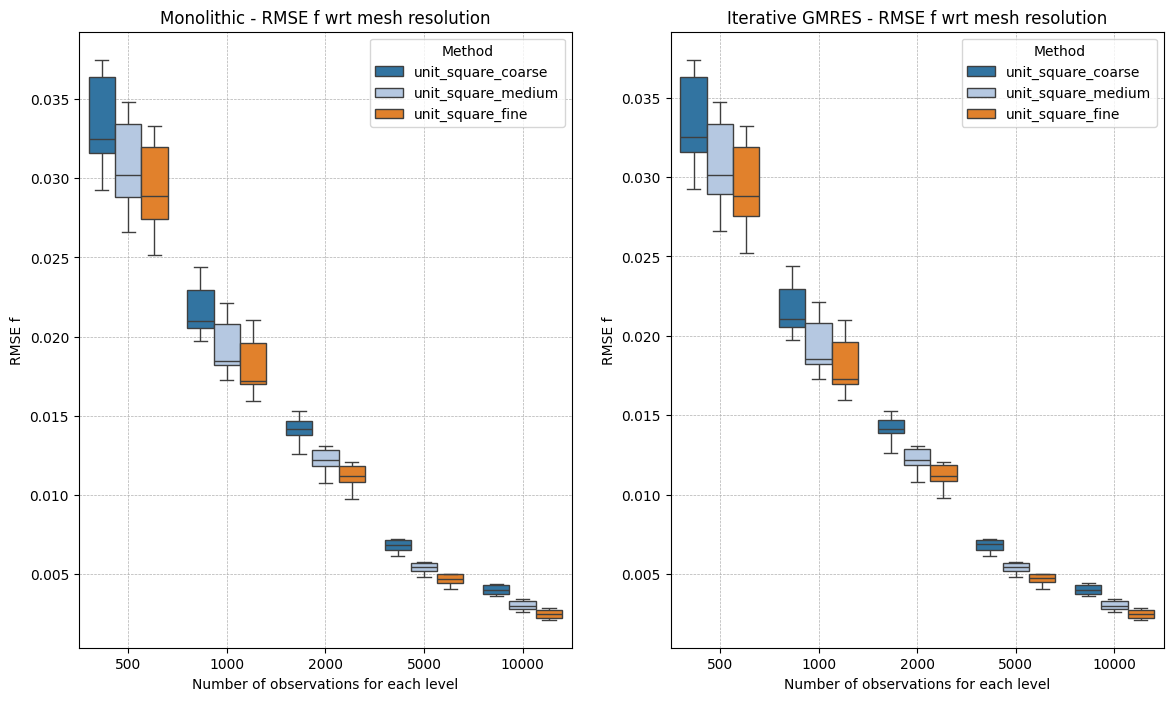

In [245]:
# RMSE vs mesh
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
sns.boxplot(x='n_obs', y='rmse_f', hue='mesh', data=mono, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Monolithic - RMSE f wrt mesh resolution")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('RMSE f')
plt.subplot(1,2,2)
sns.boxplot(x='n_obs', y='rmse_f', hue='mesh', data=rich, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Iterative GMRES - RMSE f wrt mesh resolution")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('RMSE f')

Text(0, 0.5, 'RMSE f')

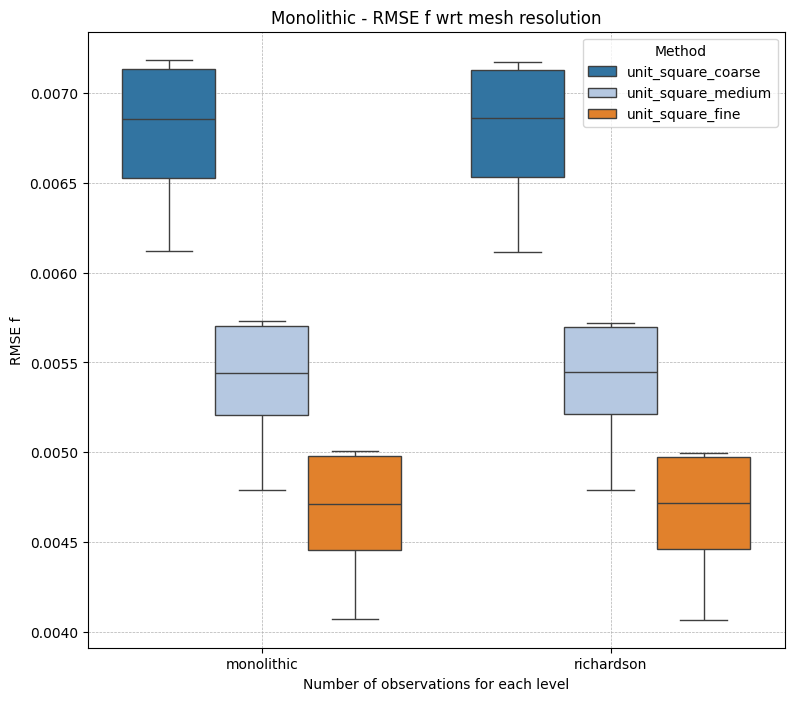

In [246]:
plt.figure(figsize=(9,8))
sns.boxplot(x='policyID', y='rmse_f', hue='mesh', data=data.query("n_obs == 5000"), palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Monolithic - RMSE f wrt mesh resolution")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('RMSE f')

Text(0, 0.5, 'Duration [s]')

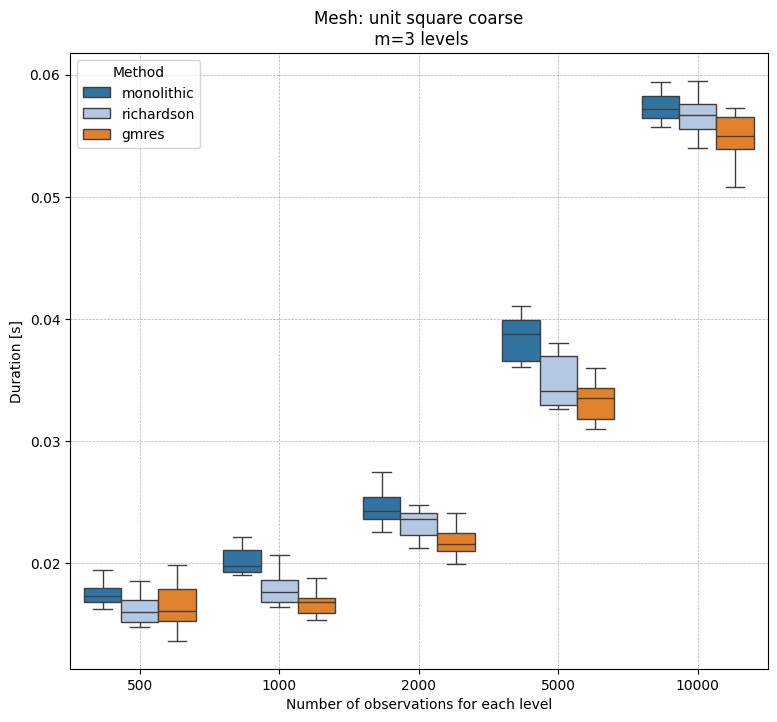

In [ ]:
usc_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_coarse")
usc_rich = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_coarse")
usc_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_coarse")

data = pd.DataFrame(pd.concat([usc_mono, usc_rich, usc_gmres]))

plt.figure(figsize=(9,8))
sns.boxplot(x='n_obs', y='time', hue='policyID', data=data, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square coarse/n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Duration [s]')

Text(0, 0.5, 'Duration [s]')

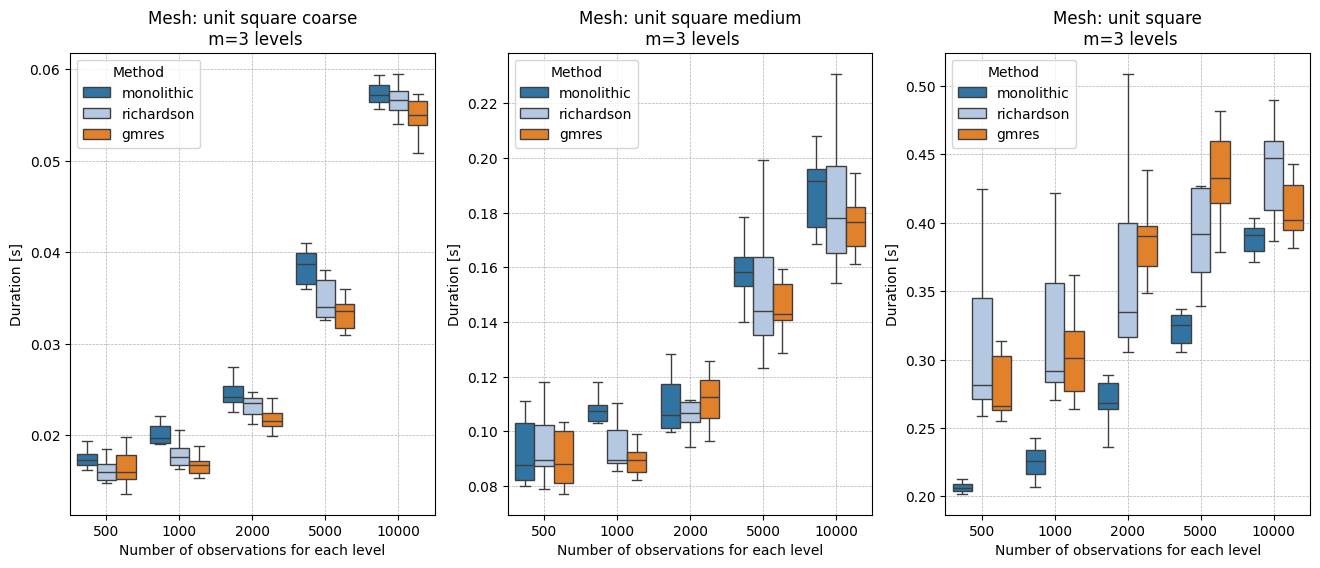

In [287]:
usc_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_coarse")
usc_rich = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_coarse")
usc_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_coarse")

usc = pd.DataFrame(pd.concat([usc_mono, usc_rich, usc_gmres]))

usm_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_medium")
usm_rich = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_medium")
usm_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_medium")

usm = pd.DataFrame(pd.concat([usm_mono, usm_rich, usm_gmres]))

us_mono = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_us/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_medium")
us_rich = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_us/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_medium")
us_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_us/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_medium")

us = pd.DataFrame(pd.concat([us_mono, us_rich, us_gmres]))

plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
sns.boxplot(x='n_obs', y='time', hue='policyID', data=usc, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square coarse\n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Duration [s]')
plt.subplot(1,3,2)
sns.boxplot(x='n_obs', y='time', hue='policyID', data=usm, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square medium\n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Duration [s]')
plt.subplot(1,3,3)
sns.boxplot(x='n_obs', y='time', hue='policyID', data=us, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square\n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Duration [s]')

Text(0, 0.5, 'Duration solve [s]')

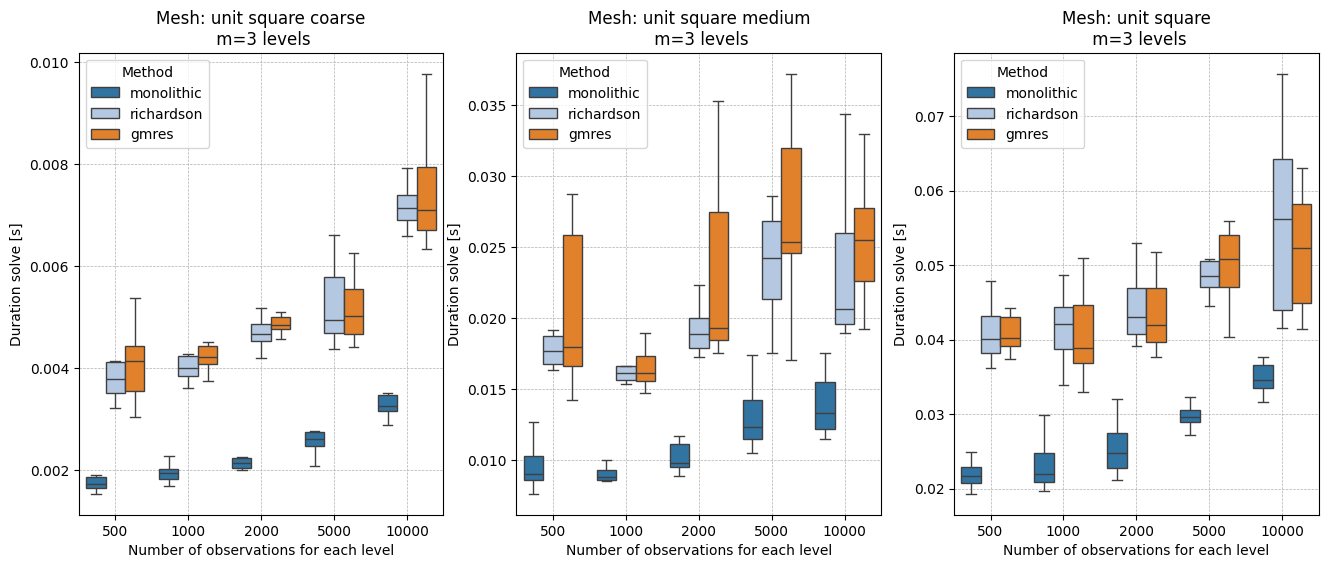

In [288]:
# solve 
usc_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_coarse")
usc_rich = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_coarse")
usc_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_coarse")

usc = pd.DataFrame(pd.concat([usc_mono, usc_rich, usc_gmres]))

usm_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_medium")
usm_rich = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_medium")
usm_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_medium")

usm = pd.DataFrame(pd.concat([usm_mono, usm_rich, usm_gmres]))

us_mono = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_us/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_medium")
us_rich = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_us/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_medium")
us_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_us/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_medium")

us = pd.DataFrame(pd.concat([us_mono, us_rich, us_gmres]))

plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
sns.boxplot(x='n_obs', y='time_solve', hue='policyID', data=usc, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square coarse\n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Duration solve [s]')
plt.subplot(1,3,2)
sns.boxplot(x='n_obs', y='time_solve', hue='policyID', data=usm, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square medium\n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Duration solve [s]')
plt.subplot(1,3,3)
sns.boxplot(x='n_obs', y='time_solve', hue='policyID', data=us, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square\n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('Duration solve [s]')

Text(0, 0.5, 'RMSE f')

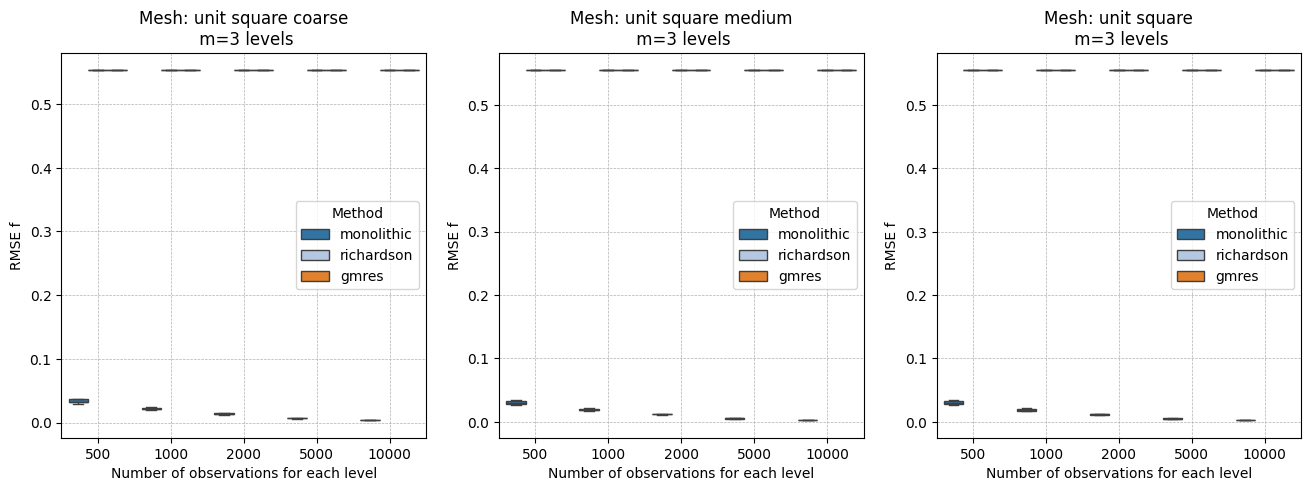

In [296]:
# solve 
usc_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_coarse")
usc_rich = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_coarse")
usc_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/mesh_usc/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_coarse")

usc = pd.DataFrame(pd.concat([usc_mono, usc_rich, usc_gmres]))

usm_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_medium")
usm_rich = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_medium")
usm_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_medium/mesh_usm/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_medium")

usm = pd.DataFrame(pd.concat([usm_mono, usm_rich, usm_gmres]))

us_mono = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_us/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", mesh = "unit_square_medium")
us_rich = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_us/output/richardson_gen.txt", sep=" ").assign(policyID = "richardson", mesh = "unit_square_medium")
us_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square/mesh_us/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", mesh = "unit_square_medium")

us = pd.DataFrame(pd.concat([us_mono, us_rich, us_gmres]))

plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
sns.boxplot(x='n_obs', y='rmse_f', hue='policyID', data=usc, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square coarse\n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('RMSE f')
plt.subplot(1,3,2)
sns.boxplot(x='n_obs', y='rmse_f', hue='policyID', data=usm, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square medium\n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('RMSE f')
plt.subplot(1,3,3)
sns.boxplot(x='n_obs', y='rmse_f', hue='policyID', data=us, palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.title(f"Mesh: unit square\n m=3 levels")
plt.legend(title='Method')
plt.xlabel('Number of observations for each level')
plt.ylabel('RMSE f')

In [352]:
# NA 

na_000_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_0/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", na_perc = 0.00)
na_000_iter = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_0/output/richardson_gen.txt", sep=" ").assign(policyID = "iterative", na_perc = 0.00)
na_000_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_0/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", na_perc = 0.00)

na_000 = pd.DataFrame(pd.concat([na_000_mono, na_000_iter, na_000_gmres]))

na_005_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_50/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", na_perc = 0.05)
na_005_iter = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_50/output/richardson_gen.txt", sep=" ").assign(policyID = "iterative", na_perc = 0.05)
na_005_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_50/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", na_perc = 0.05)

na_005 = pd.DataFrame(pd.concat([na_005_mono, na_005_iter, na_005_gmres]))

na_010_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_100/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", na_perc = 0.10)
na_010_iter = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_100/output/richardson_gen.txt", sep=" ").assign(policyID = "iterative", na_perc = 0.10)
na_010_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_100/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", na_perc = 0.10)

na_010 = pd.DataFrame(pd.concat([na_010_mono, na_010_iter, na_010_gmres]))

na_015_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_150/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", na_perc = 0.15)
na_015_iter = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_150/output/richardson_gen.txt", sep=" ").assign(policyID = "iterative", na_perc = 0.15)
na_015_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_150/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", na_perc = 0.15)

na_015 = pd.DataFrame(pd.concat([na_015_mono, na_015_iter, na_015_gmres]))

na_020_mono = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_200/output/monolithic_gen.txt", sep=" ").assign(policyID = "monolithic", na_perc = 0.20)
na_020_iter = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_200/output/richardson_gen.txt", sep=" ").assign(policyID = "iterative", na_perc = 0.20)
na_020_gmres = pd.read_csv("../data/models/mixed_srpde/unit_square_coarse/na_variation_200/output/richardson_gmres_gen.txt", sep=" ").assign(policyID = "gmres", na_perc = 0.20)

na_020 = pd.DataFrame(pd.concat([na_020_mono, na_020_iter, na_020_gmres]))

data = pd.DataFrame(pd.concat([na_000, na_005, na_010, na_015, na_020]))
data

,time_init,time_solve,time,rmse_f,rmse_beta,rmse_alpha,n_obs,m,rmse_f_1,rmse_f_2,rmse_f_3,policyID,na_perc
0,0.018890,0.001789,0.020678,0.020476,0.005169,0.001022,1000,3,0.054615,0.001313,0.005499,monolithic,0.0
1,0.016615,0.001481,0.018095,0.021266,0.005254,0.001936,1000,3,0.053612,0.003601,0.006586,monolithic,0.0
2,0.016513,0.001716,0.018229,0.024797,0.005206,0.007227,1000,3,0.065769,0.001271,0.007352,monolithic,0.0
3,0.018485,0.002056,0.020541,0.023336,0.006839,0.001296,1000,3,0.061039,0.001628,0.007341,monolithic,0.0
4,0.020403,0.002203,0.022606,0.019700,0.005268,0.000236,1000,3,0.051253,0.002383,0.005463,monolithic,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.009812,0.003142,0.012954,0.553175,0.267544,0.158549,1000,3,0.226757,0.183333,1.249430,gmres,0.2
6,0.011244,0.003687,0.014931,0.553175,0.272504,0.148830,1000,3,0.226757,0.183333,1.249430,gmres,0.2
7,0.009931,0.003391,0.013321,0.553175,0.280700,0.149957,1000,3,0.226757,0.183333,1.249430,gmres,0.2
8,0.010653,0.003735,0.014388,0.553175,0.259396,0.145101,1000,3,0.226757,0.183333,1.249430,gmres,0.2


In [346]:
na_000

,time_init,time_solve,time,rmse_f,rmse_beta,rmse_alpha,n_obs,m,rmse_f_1,rmse_f_2,rmse_f_3,policyID,na_perc
0,0.018890,0.001789,0.020678,0.020476,0.005169,0.001022,1000,3,0.054615,0.001313,0.005499,monolithic,0.0
1,0.016615,0.001481,0.018095,0.021266,0.005254,0.001936,1000,3,0.053612,0.003601,0.006586,monolithic,0.0
2,0.016513,0.001716,0.018229,0.024797,0.005206,0.007227,1000,3,0.065769,0.001271,0.007352,monolithic,0.0
3,0.018485,0.002056,0.020541,0.023336,0.006839,0.001296,1000,3,0.061039,0.001628,0.007341,monolithic,0.0
4,0.020403,0.002203,0.022606,0.019700,0.005268,0.000236,1000,3,0.051253,0.002383,0.005463,monolithic,0.0
5,0.016020,0.001737,0.017757,0.021042,0.005258,0.000131,1000,3,0.054962,0.001412,0.006751,monolithic,0.0
6,0.016484,0.001767,0.018250,0.020506,0.005361,0.001813,1000,3,0.051184,0.001436,0.008898,monolithic,0.0
7,0.016821,0.001769,0.018590,0.022100,0.006540,0.001307,1000,3,0.058954,0.001348,0.005999,monolithic,0.0
8,0.015296,0.001728,0.017024,0.020005,0.005507,0.001435,1000,3,0.052646,0.001261,0.006108,monolithic,0.0
9,0.017715,0.001853,0.019568,0.020562,0.005249,0.000522,1000,3,0.053514,0.001317,0.006854,monolithic,0.0


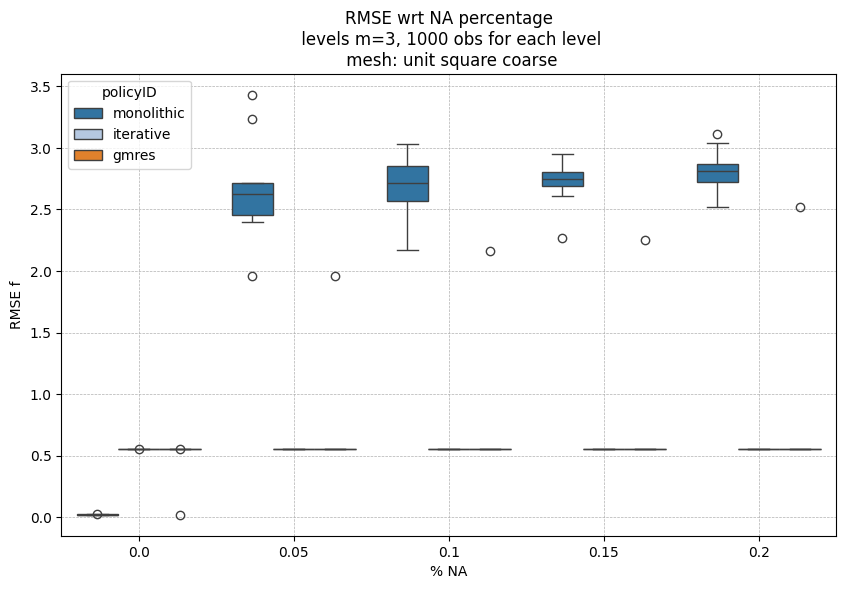

In [353]:
plt.figure(figsize=(10,6))
plt.title('RMSE wrt NA percentage\n levels m=3, 1000 obs for each level\n mesh: unit square coarse')
plt.ylabel('RMSE f')
plt.xlabel('% NA')
sns.boxplot(x='na_perc', y='rmse_f', hue='policyID', data = data, palette='tab20')
plt.grid(ls="--",linewidth=0.5)


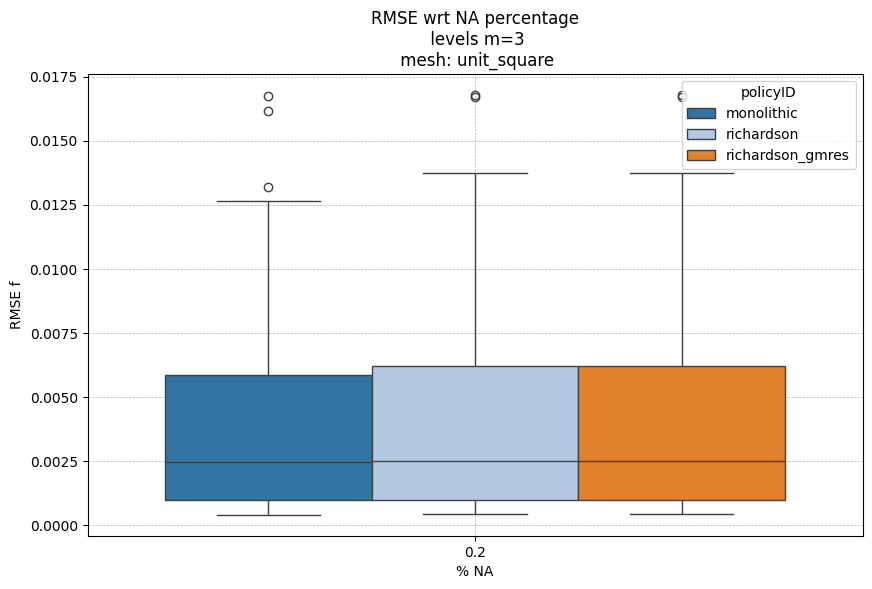

In [476]:
# NA con mesh unit_square

def plot_na(meshID):
    plt.figure(figsize=(10,6))
    plt.title(f'RMSE wrt NA percentage\n levels m=3\n mesh: {meshID}')
    plt.ylabel('RMSE f')
    plt.xlabel('% NA')
    sns.boxplot(x='na_perc', y='rmse_f', hue='policyID', data = data, palette='tab20')
    plt.grid(ls="--",linewidth=0.5)
    plt.show()

meshID = "unit_square"

data = pd.DataFrame()

for policy in ["monolithic", "richardson", "richardson_gmres"]:
    test_name = "same_locs_true/"
    path = "../data/models/mixed_srpde/" + meshID + "/" + test_name + "/output/" + policy + ".txt"
    temp_data = pd.read_csv(path, sep=" ").assign(policyID = policy, mesh = meshID)

    data = pd.concat([data, temp_data])

plot_na(meshID=meshID)

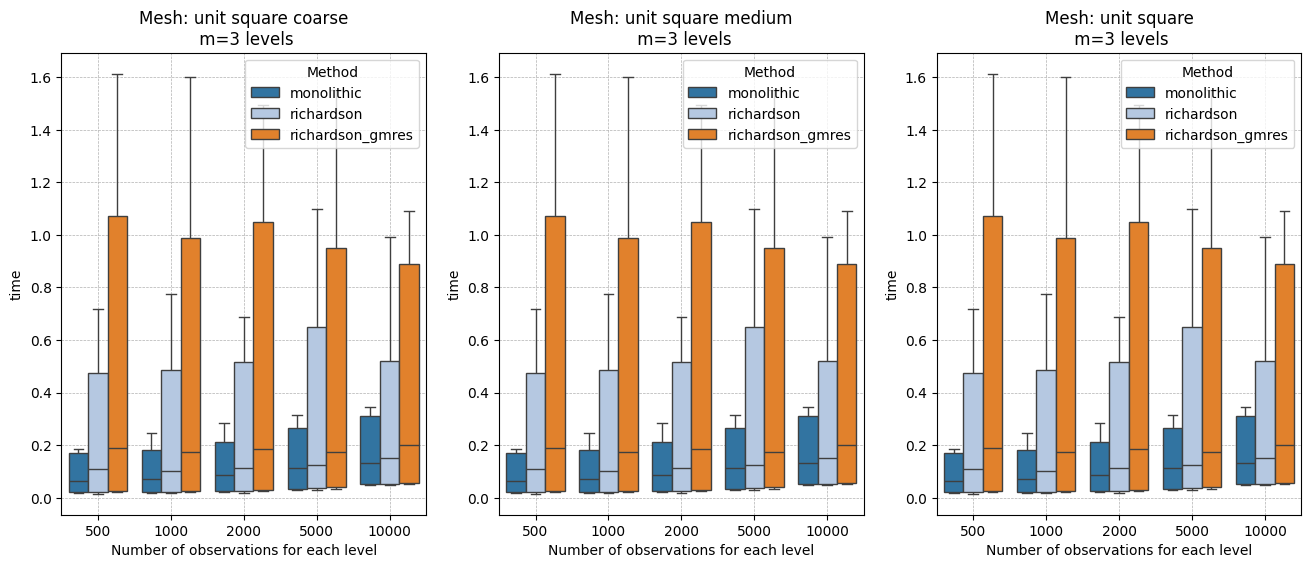

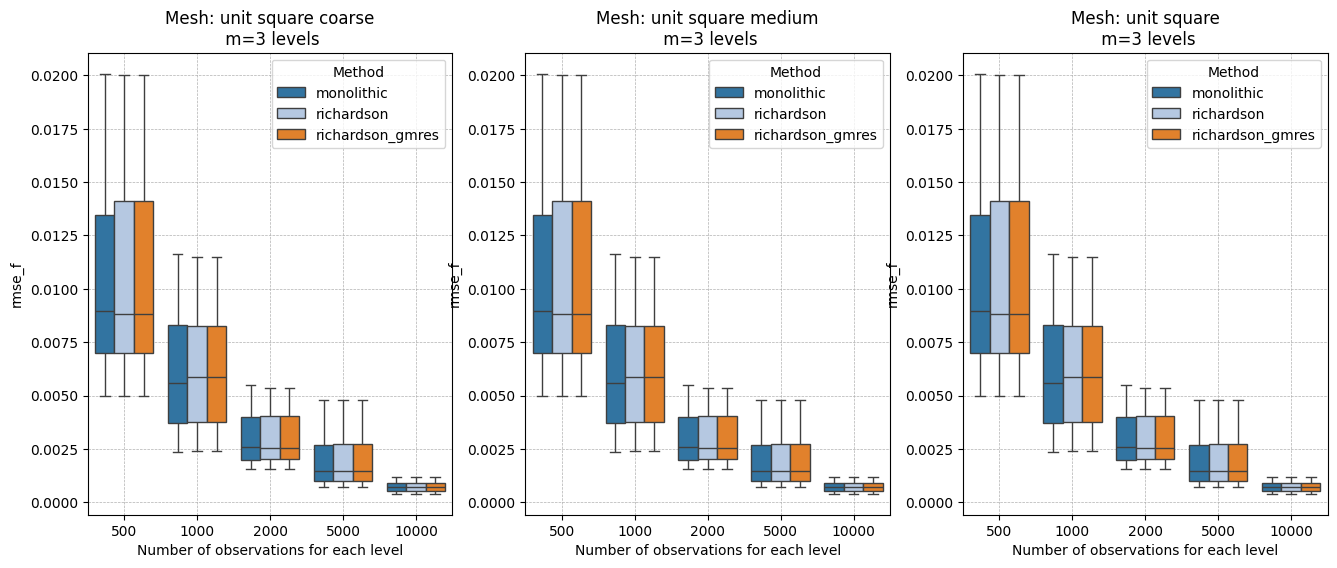

In [462]:
# MESH VARIATION

def plot_mesh(var_name):
    plt.figure(figsize=(16,6))
    plt.subplot(1,3,1)
    sns.boxplot(x='n_obs', y=var_name, hue='policyID', data=data, palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Mesh: unit square coarse\n m=3 levels")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel(f'{var_name}')
    plt.subplot(1,3,2)
    sns.boxplot(x='n_obs', y=var_name, hue='policyID', data=data, palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Mesh: unit square medium\n m=3 levels")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel(f'{var_name}')
    plt.subplot(1,3,3)
    sns.boxplot(x='n_obs', y=var_name, hue='policyID', data=data, palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Mesh: unit square\n m=3 levels")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel(f'{var_name}')
    plt.show()

data = pd.DataFrame()

for meshID in ["unit_square", "unit_square_coarse", "unit_square_medium"]:
    for policy in ["monolithic", "richardson", "richardson_gmres"]:
        test_name = "same_locs_true/"
        path = "../data/models/mixed_srpde/" + meshID + "/" + test_name + "/output/" + policy + ".txt"
        temp_data = pd.read_csv(path, sep=" ").assign(policyID = policy, mesh = meshID).query("na_perc == 0")

        data = pd.concat([data, temp_data])

plot_mesh('time')
plot_mesh('rmse_f')

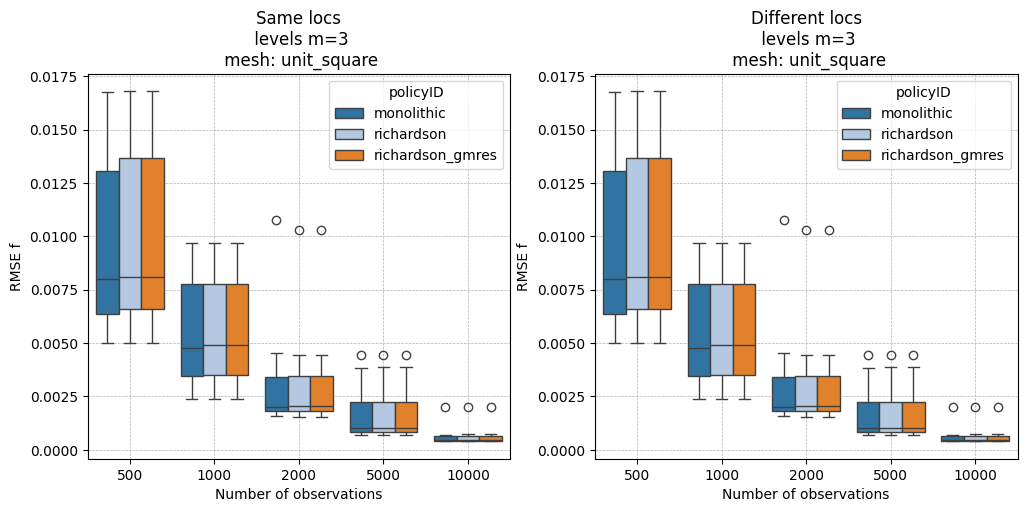

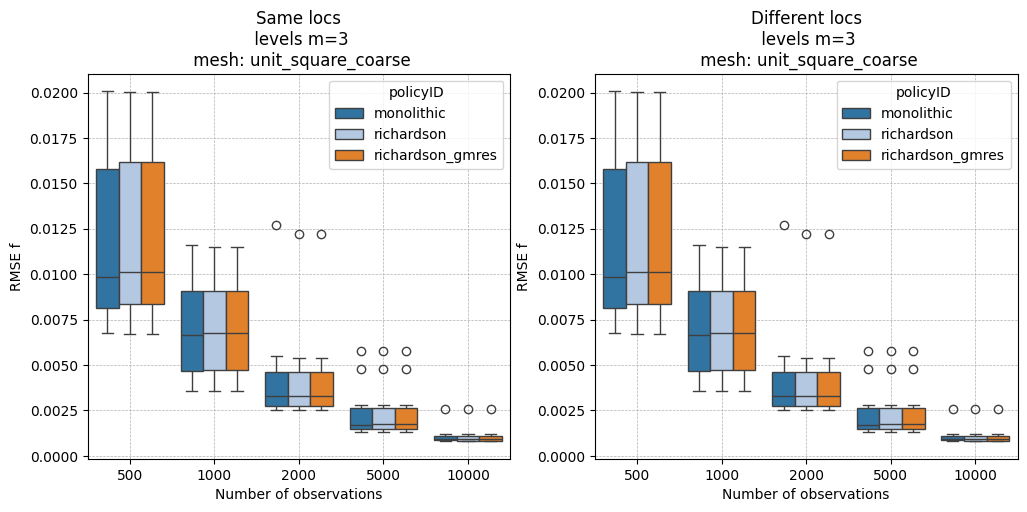

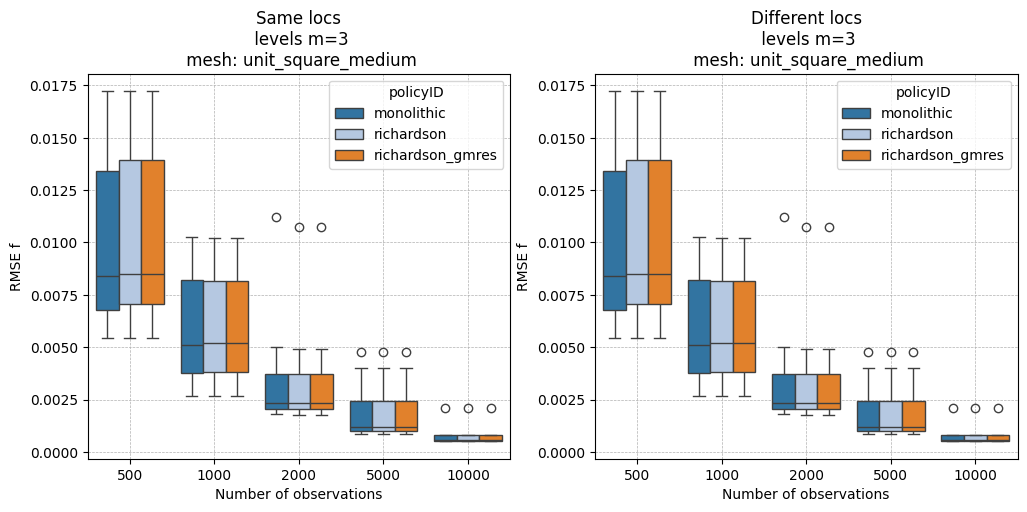

In [444]:
# test SAME LOCS vs DIFF LOCS

def plot_locs(meshID):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.title(f'Same locs\n levels m=3\n mesh: {meshID}')
    plt.ylabel('RMSE f')
    plt.xlabel('Number of observations')
    sns.boxplot(x='n_obs', y='rmse_f', hue='policyID', data = data.query(f"same_locs == 'true' and mesh == '{meshID}'"), palette='tab20')
    plt.grid(ls="--",linewidth=0.5)
    plt.subplot(1,2,2)
    plt.title(f'Different locs\n levels m=3\n mesh: {meshID}')
    plt.ylabel('RMSE f')
    plt.xlabel('Number of observations')
    sns.boxplot(x='n_obs', y='rmse_f', hue='policyID', data = data.query(f"same_locs == 'false' and mesh == '{meshID}'"), palette='tab20')
    plt.grid(ls="--",linewidth=0.5)
    plt.show()

data = pd.DataFrame()

for bools in ["true", "false"]:
    for meshID in ["unit_square", "unit_square_coarse", "unit_square_medium"]:
        for policy in ["monolithic", "richardson", "richardson_gmres"]:
            test_name = "same_locs_" + bools
            path = "../data/models/mixed_srpde/" + meshID + "/" + test_name + "/output/" + policy + ".txt"
            temp_data = pd.read_csv(path, sep=" ").assign(policyID = policy, mesh = meshID, na_perc = 0.0, same_locs = bools)

            data = pd.concat([data, temp_data])

plot_locs(meshID="unit_square")
plot_locs(meshID="unit_square_coarse")
plot_locs(meshID="unit_square_medium")


In [421]:
data

,time_init,time_solve,time,rmse_f,rmse_f_1,rmse_f_2,rmse_f_3,rmse_beta,rmse_alpha,n_obs,NA
0,0.062247,0.006851,0.069098,0.004779,0.011596,0.000615,0.002126,0.004845,0.004922,500,0.00
1,0.078485,0.006729,0.085213,0.030444,0.078182,0.006097,0.007053,0.010757,0.029043,500,0.00
2,0.118434,0.017079,0.135513,0.007544,0.015376,0.000431,0.006827,0.004785,0.008819,500,0.00
3,0.050799,0.006221,0.057020,0.022063,0.061884,0.001320,0.002985,0.008782,0.021471,500,0.00
4,0.110113,0.009903,0.120016,0.422387,0.029887,0.131789,1.105480,0.019418,0.604684,500,0.05
...,...,...,...,...,...,...,...,...,...,...,...
95,0.302730,0.226692,0.529422,0.572557,1.534690,0.121150,0.061834,0.135918,0.907315,8000,0.15
96,0.270368,0.036447,0.306815,0.487797,0.056128,1.021700,0.385560,0.034475,0.538842,8000,0.20
97,0.313018,0.230570,0.543587,0.172142,0.409014,0.055460,0.051953,0.260545,0.158045,8000,0.20
98,0.242250,0.046975,0.289225,0.161090,0.176403,0.094634,0.212233,0.089844,0.387860,8000,0.20


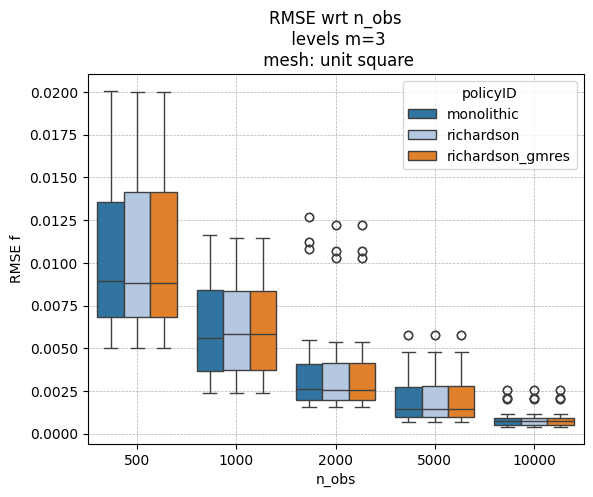

In [450]:
data = pd.DataFrame()

for bools in ["true", "false"]:
    for meshID in ["unit_square", "unit_square_coarse", "unit_square_medium"]:
        for policy in ["monolithic", "richardson", "richardson_gmres"]:
            test_name = "same_locs_" + bools
            path = "../data/models/mixed_srpde/" + meshID + "/" + test_name + "/output/" + policy + ".txt"
            temp_data = pd.read_csv(path, sep=" ").assign(policyID = policy, mesh = meshID, na_perc = 0.0, same_locs = bools)

            data = pd.concat([data, temp_data])

plt.title('RMSE wrt n_obs\n levels m=3\n mesh: unit square')
plt.ylabel('RMSE f')
plt.xlabel('n_obs')
sns.boxplot(x='n_obs', y='rmse_f', hue='policyID', data = data, palette='tab20')
plt.grid(ls="--",linewidth=0.5)
plt.show()

In [2]:
# SAME/DIFF LOCATIONS DIFF NA

    # std::string test_name = "same_locations_diff_NA/";
    # int seed = 23872; 
    # double lambda = 1; 
    # int memory = 3;             // GMRES param
    # bool same_locs = 0;
    # std::string meshID = "unit_square_medium";
    # std::size_t m = 3;
    # std::size_t n_sim = 100;     
    # DMatrix<double> beta = DMatrix<double>::Zero(2,1);
    # beta(0,0) = -2.; beta(1,0) = 1.;
    # DMatrix<double> alpha = DMatrix<double>::Zero(3,1);
    # alpha(0,0) = -0.5; alpha(1,0) = 0.; alpha(2,0) = 0.5;
    # DMatrix<int> n_obs = DMatrix<int>::Zero(5,m);
    # n_obs(0,0) = 500; n_obs(1,0) = 1000; n_obs(2,0) = 2000; 
    # n_obs(3,0) = 4000; n_obs(4,0) = 8000;

data = pd.DataFrame()

for meshID in ["unit_square", "unit_square_coarse", "unit_square_medium"]:
    for test_name in ["diff_locations_diff_NA", "same_locations_diff_NA"]:
            for policy in ["monolithic", "richardson", "richardson_gmres"]:

                same_loc = "true" if test_name == "same_locations_diff_NA" else "false"

                path = "../data/models/mixed_srpde/" + meshID + "/" + test_name + "/output/" + policy + ".txt"
                temp_data = pd.read_csv(path, sep=" ").assign(policyID = policy, mesh = meshID, same_locs = same_loc)

                data = pd.concat([data, temp_data])

data
data.to_csv(path_or_buf="../data/models/mixed_srpde/data.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/models/mixed_srpde/unit_square/diff_locations_diff_NA/output/richardson_gmres.txt'

In [56]:
# SAME/DIFF LOCATIONS DIFF NA

    # std::string test_name = "same_locations_diff_NA/";
    # int seed = 23872; 
    # double lambda = 1e-3; 
    # int memory = 3;             // GMRES param
    # bool same_locs = 0;
    # std::string meshID = "unit_square_medium";
    # std::size_t m = 3;
    # std::size_t n_sim = 100;     
    # DMatrix<double> beta = DMatrix<double>::Zero(2,1);
    # beta(0,0) = -2.; beta(1,0) = 1.;
    # DMatrix<double> alpha = DMatrix<double>::Zero(3,1);
    # alpha(0,0) = -0.5; alpha(1,0) = 0.; alpha(2,0) = 0.5;
    # DMatrix<int> n_obs = DMatrix<int>::Zero(5,m);
    # n_obs(0,0) = 500; n_obs(1,0) = 1000; n_obs(2,0) = 2000; 
    # n_obs(3,0) = 4000; n_obs(4,0) = 8000;
import pandas as pd
data = pd.DataFrame()

for meshID in ["unit_square_coarse", "unit_square_medium", "unit_square"]:
    for test_name in ["diff_locations_diff_NA", "same_locations_diff_NA"]:
            for policy in ["monolithic", "richardson", "richardson_gmres"]:

                same_loc = "true" if test_name == "same_locations_diff_NA" else "false"

                path = "../data/models/mixed_srpde/" + meshID + "/" + test_name + "/output/" + policy + ".txt"
                temp_data = pd.read_csv(path, sep=" ").assign(policyID = policy, mesh = meshID, same_locs = same_loc)

                data = pd.concat([data, temp_data])

data

,time_init,time_solve,time,rmse_f,rmse_f_1,rmse_f_2,rmse_f_3,rmse_beta,rmse_alpha,n_obs,na_perc,policyID,mesh,same_locs
0,0.021752,0.002014,0.023766,0.004779,0.011596,0.000615,0.002126,0.004845,0.004922,500,0.0,monolithic,unit_square_coarse,false
1,0.046770,0.002656,0.049425,0.030444,0.078182,0.006097,0.007053,0.010757,0.029043,500,0.0,monolithic,unit_square_coarse,false
2,0.019172,0.002045,0.021217,0.007544,0.015376,0.000431,0.006827,0.004785,0.008819,500,0.0,monolithic,unit_square_coarse,false
3,0.020163,0.002232,0.022395,0.022063,0.061884,0.001320,0.002985,0.008782,0.021471,500,0.0,monolithic,unit_square_coarse,false
4,0.031753,0.002027,0.033781,0.004393,0.012207,0.000176,0.000796,0.005235,0.003417,500,0.0,monolithic,unit_square_coarse,false
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.592774,1.184050,1.776830,2.921720,4.462710,2.735740,1.566720,2.012010,0.177573,8000,0.2,richardson_gmres,unit_square,true
496,0.626796,1.238490,1.865290,2.937380,4.431890,2.770890,1.609360,2.024620,0.167168,8000,0.2,richardson_gmres,unit_square,true
497,0.539856,1.106250,1.646110,2.921390,4.408370,2.742150,1.613650,2.022290,0.164651,8000,0.2,richardson_gmres,unit_square,true
498,0.504578,1.217510,1.722090,2.890340,4.302700,2.805270,1.563040,2.003250,0.161945,8000,0.2,richardson_gmres,unit_square,true


In [50]:
data.query('rmse_f > 1000')

,time_init,time_solve,time,rmse_f,rmse_f_1,rmse_f_2,rmse_f_3,rmse_beta,rmse_alpha,n_obs,na_perc,policyID,mesh,same_locs
89,0.011524,0.010243,0.021768,3.089280e+04,3.920460e+00,9.267350e+04,1.059410e+00,4.444210e+03,1.847710e+04,500,0.20,richardson,unit_square_coarse,false
278,0.018231,0.012326,0.030557,5.071410e+03,4.415930e+00,1.520750e+04,2.258900e+00,9.443600e+02,3.411480e+03,2000,0.15,richardson,unit_square_coarse,false
365,0.028168,0.015877,0.044045,5.332480e+03,4.139130e+00,1.599180e+04,1.480520e+00,8.812030e+02,3.862880e+03,4000,0.15,richardson,unit_square_coarse,false
20,0.013402,0.031558,0.044960,1.895510e+08,4.256680e+04,5.529790e+07,5.133140e+08,3.596880e+07,4.822320e+07,500,0.05,richardson_gmres,unit_square_coarse,false
21,0.012883,0.030838,0.043721,2.414560e+09,1.411870e+05,7.243520e+09,2.275380e+04,2.109170e+08,8.403420e+08,500,0.05,richardson_gmres,unit_square_coarse,false
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,0.347937,1.942260,2.290200,1.414890e+15,3.585680e+09,4.244660e+15,2.477010e+09,1.503190e+14,6.005820e+14,8000,0.20,richardson_gmres,unit_square,false
492,0.365134,1.862670,2.227810,2.663590e+03,4.249030e+00,7.880270e+03,1.062530e+02,1.934590e+02,4.578970e+02,8000,0.20,richardson_gmres,unit_square,false
494,0.401155,1.908430,2.309580,2.738850e+08,4.769980e+02,8.216530e+08,3.499970e+02,2.165970e+07,8.659360e+07,8000,0.20,richardson_gmres,unit_square,false
495,0.404712,1.961190,2.365910,4.794420e+27,3.225540e+21,2.006100e+21,1.438320e+28,5.855520e+26,2.342740e+27,8000,0.20,richardson_gmres,unit_square,false


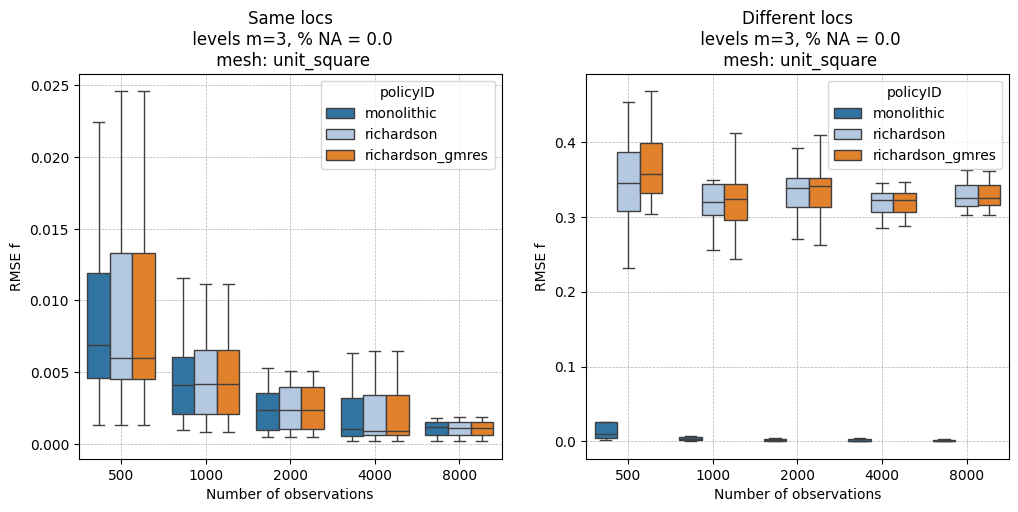

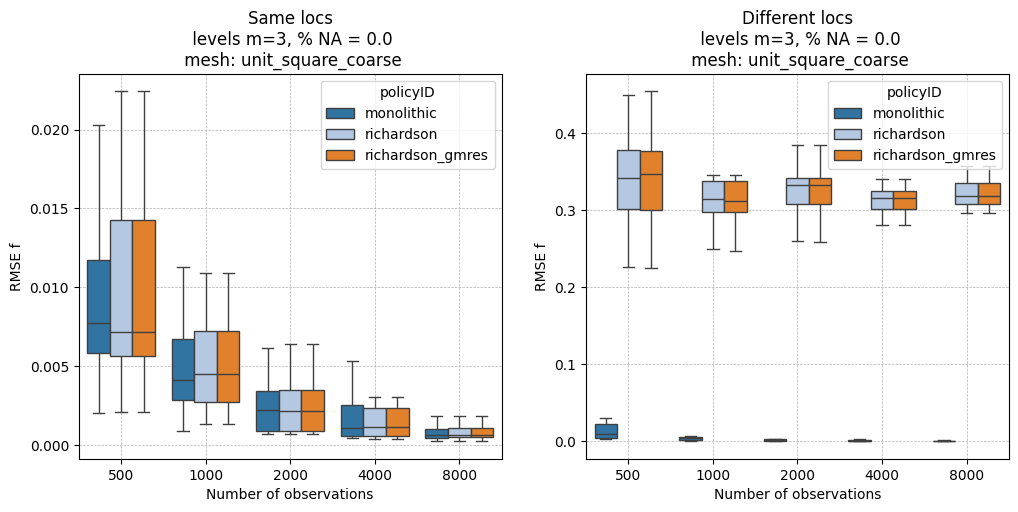

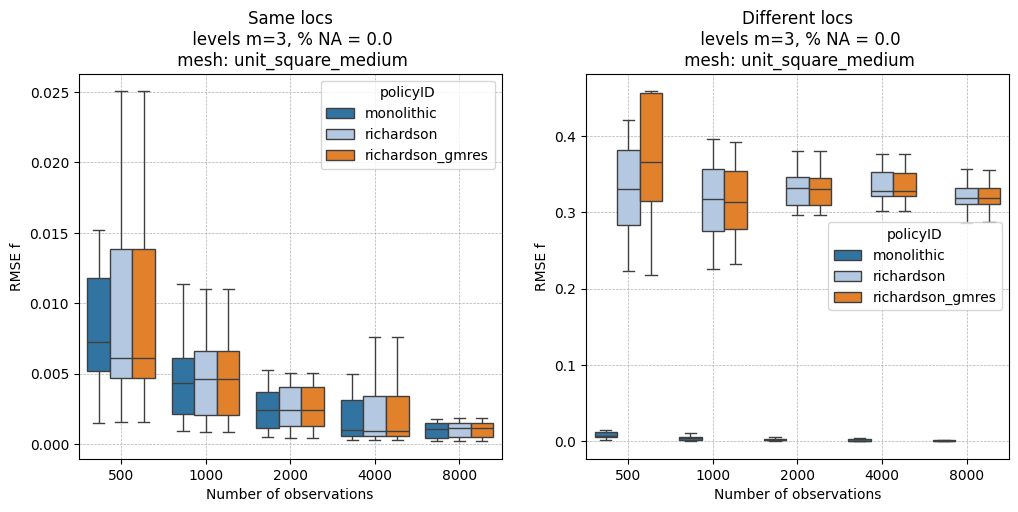

In [57]:
# test SAME LOCS vs DIFF LOCS

def plot_locs(meshID, data):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.title(f'Same locs\n levels m=3, % NA = 0.0\n mesh: {meshID}')
    plt.ylabel('RMSE f')
    plt.xlabel('Number of observations')
    sns.boxplot(x='n_obs', y='rmse_f', hue='policyID', data = data.query(f"same_locs == 'true' and mesh == '{meshID}'"), palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.subplot(1,2,2)
    plt.title(f'Different locs\n levels m=3, % NA = 0.0\n mesh: {meshID}')
    plt.ylabel('RMSE f')
    plt.xlabel('Number of observations')
    sns.boxplot(x='n_obs', y='rmse_f', hue='policyID', data = data.query(f"same_locs == 'false' and mesh == '{meshID}'"), palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.show()

data1 = data.query('na_perc == 0.0')
plot_locs(meshID="unit_square", data=data1)
plot_locs(meshID="unit_square_coarse", data=data1)
plot_locs(meshID="unit_square_medium", data=data1)


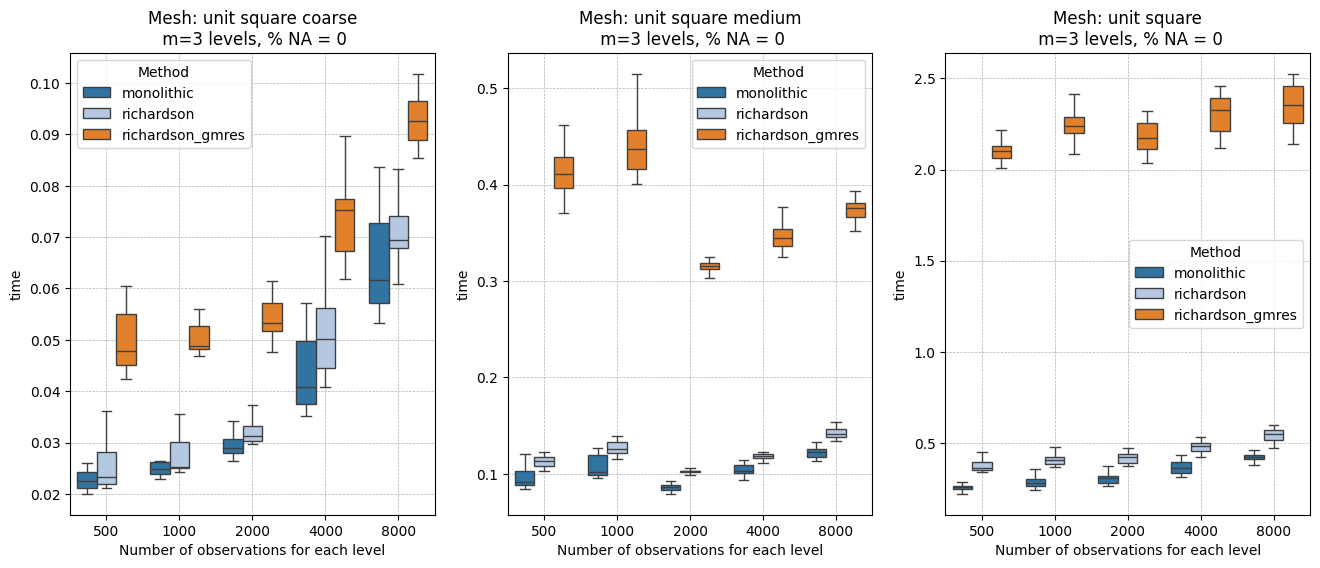

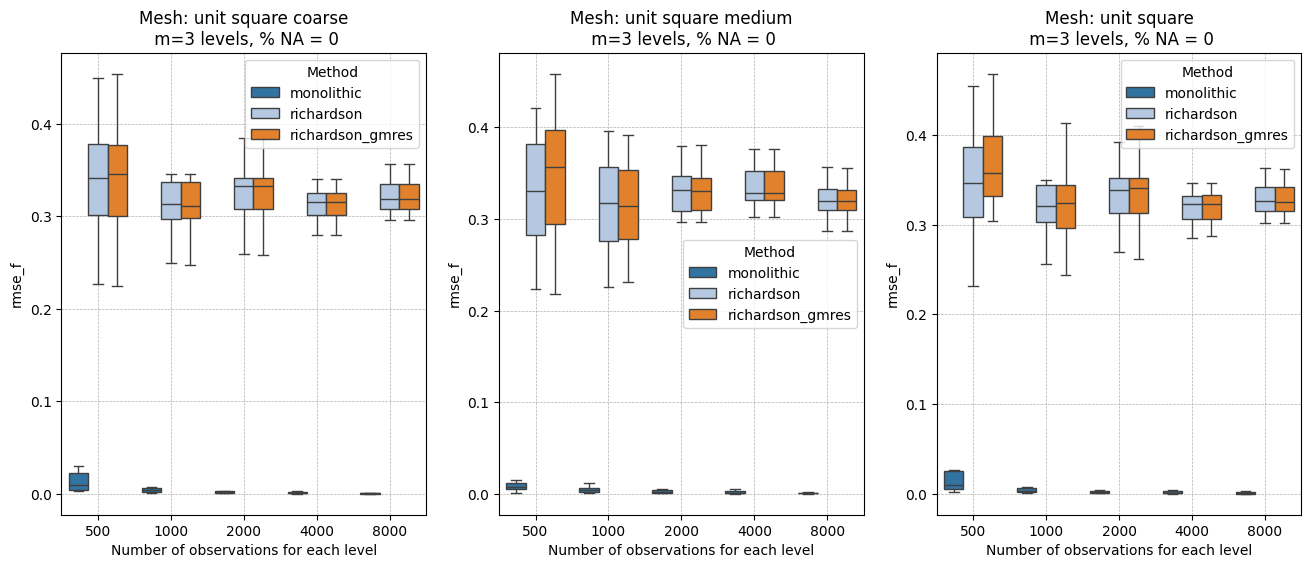

In [78]:
# MESH VARIATION

def plot_mesh(var_name, df):
    plt.figure(figsize=(16,6))
    plt.subplot(1,3,1)
    sns.boxplot(x='n_obs', y=var_name, hue='policyID', data=df.query("mesh == 'unit_square_coarse'"), palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Mesh: unit square coarse\n m=3 levels, % NA = 0")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel(f'{var_name}')
    plt.subplot(1,3,2)
    sns.boxplot(x='n_obs', y=var_name, hue='policyID', data=df.query("mesh == 'unit_square_medium'"), palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Mesh: unit square medium\n m=3 levels, % NA = 0")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel(f'{var_name}')
    plt.subplot(1,3,3)
    sns.boxplot(x='n_obs', y=var_name, hue='policyID', data=df.query("mesh == 'unit_square'"), palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Mesh: unit square\n m=3 levels, % NA = 0")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel(f'{var_name}')
    plt.show()

data2 = data.query("rmse_f < 10 and na_perc == 0 and same_locs == 'false'")
plot_mesh('time', data2)
plot_mesh('rmse_f', data2)

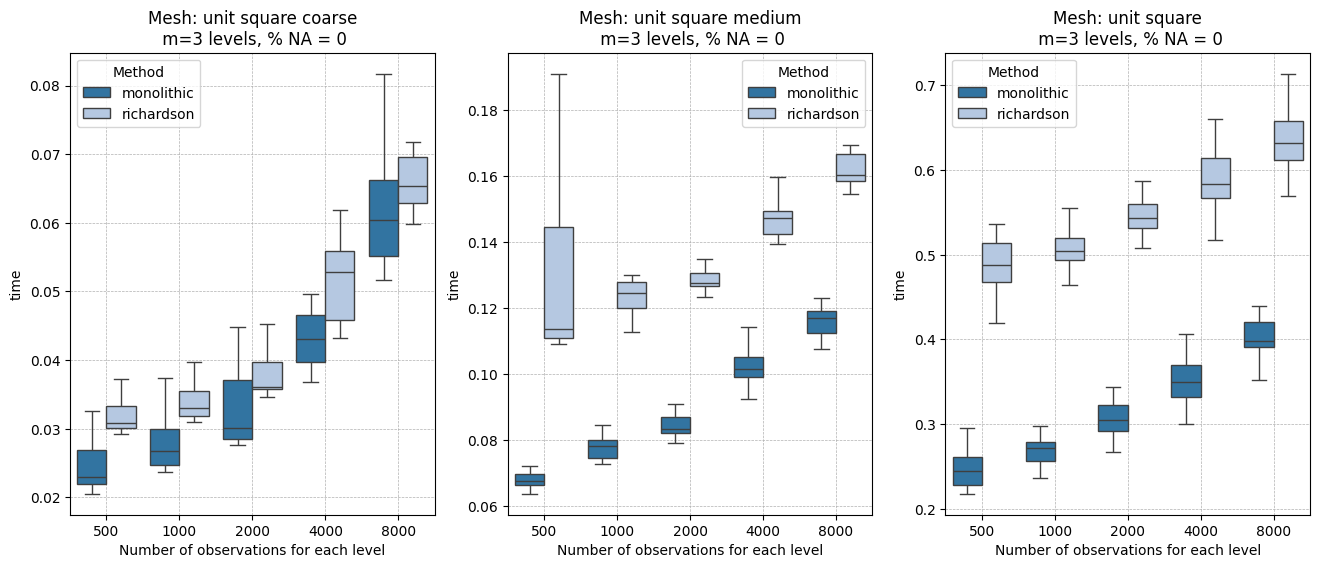

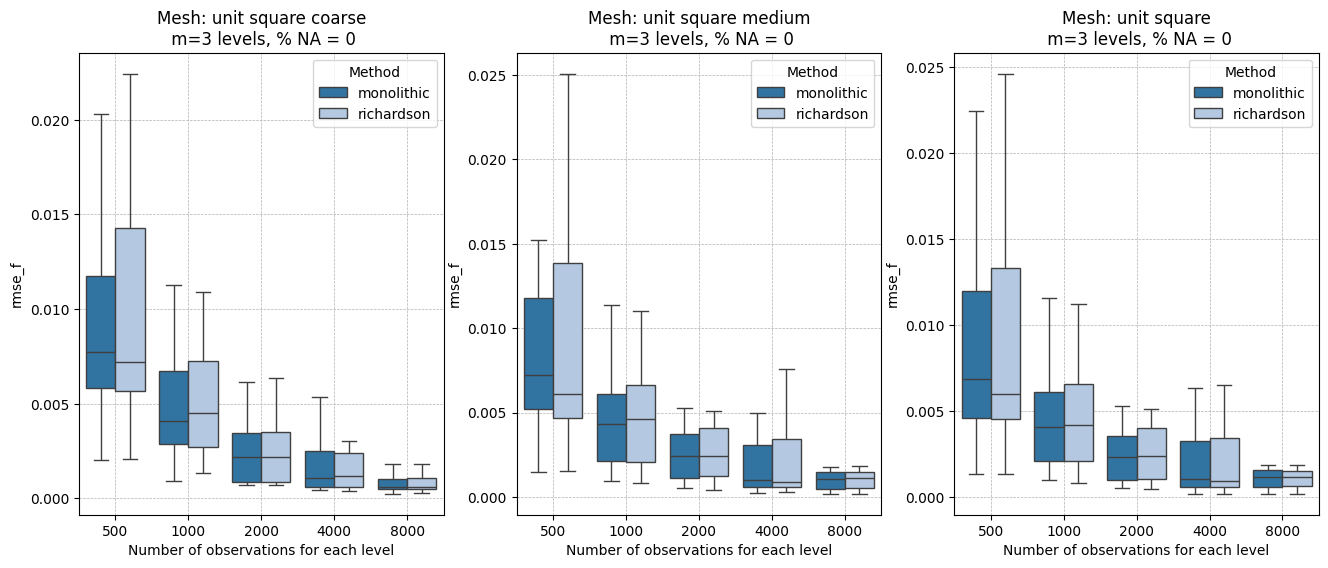

In [71]:
# MESH VARIATION SAME LOCS

def plot_mesh(var_name, df):
    plt.figure(figsize=(16,6))
    plt.subplot(1,3,1)
    sns.boxplot(x='n_obs', y=var_name, hue='policyID', data=df.query("mesh == 'unit_square_coarse'"), palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Mesh: unit square coarse\n m=3 levels, % NA = 0")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel(f'{var_name}')
    plt.subplot(1,3,2)
    sns.boxplot(x='n_obs', y=var_name, hue='policyID', data=df.query("mesh == 'unit_square_medium'"), palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Mesh: unit square medium\n m=3 levels, % NA = 0")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel(f'{var_name}')
    plt.subplot(1,3,3)
    sns.boxplot(x='n_obs', y=var_name, hue='policyID', data=df.query("mesh == 'unit_square'"), palette='tab20', showfliers=False)
    plt.grid(ls="--",linewidth=0.5)
    plt.title(f"Mesh: unit square\n m=3 levels, % NA = 0")
    plt.legend(title='Method')
    plt.xlabel('Number of observations for each level')
    plt.ylabel(f'{var_name}')
    plt.show()

data2 = data.query("rmse_f < 10 and na_perc == 0 and policyID != 'richardson_gmres' and same_locs == 'true'")
plot_mesh('time', data2)
plot_mesh('rmse_f', data2)

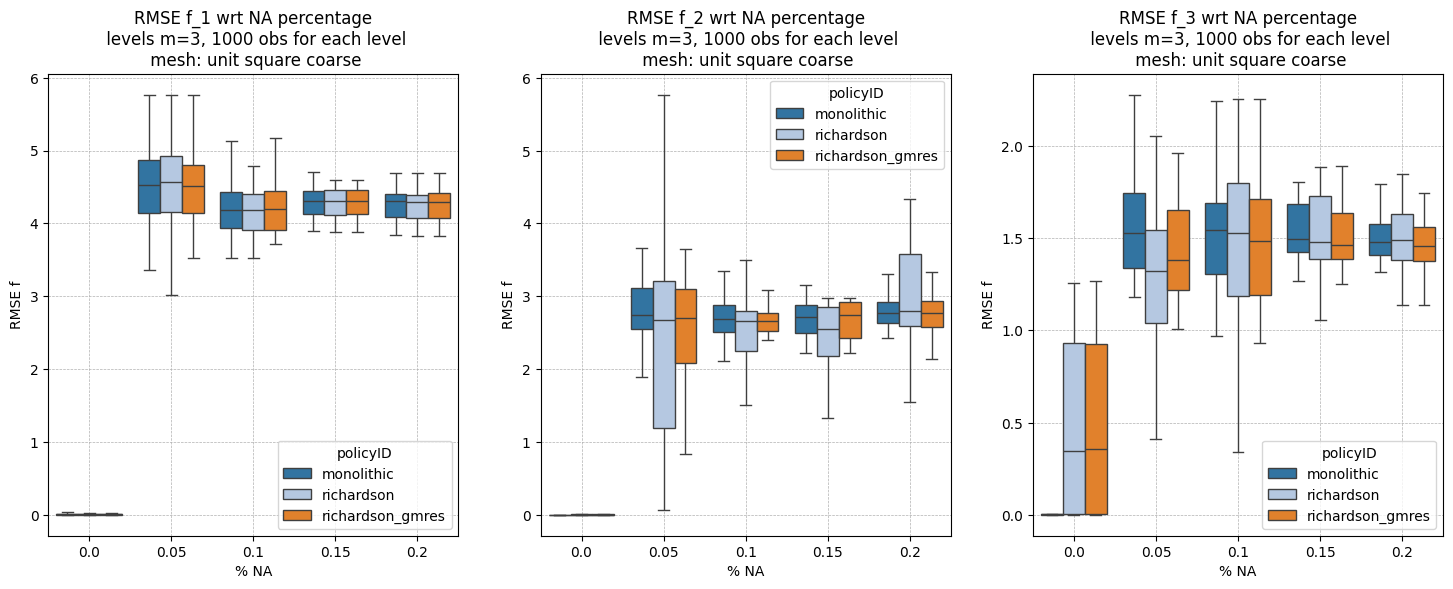

In [76]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.title('RMSE f_1 wrt NA percentage\n levels m=3, 1000 obs for each level\n mesh: unit square coarse')
plt.ylabel('RMSE f')
plt.xlabel('% NA')
sns.boxplot(x='na_perc', y='rmse_f_1', hue='policyID', data = data.query("n_obs == 1000 and mesh == 'unit_square_coarse' and rmse_f < 10"), palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.subplot(1,3,2)
plt.title('RMSE f_2 wrt NA percentage\n levels m=3, 1000 obs for each level\n mesh: unit square coarse')
plt.ylabel('RMSE f')
plt.xlabel('% NA')
sns.boxplot(x='na_perc', y='rmse_f_2', hue='policyID', data = data.query("n_obs == 1000 and mesh == 'unit_square_coarse' and rmse_f < 10"), palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
plt.subplot(1,3,3)
plt.title('RMSE f_3 wrt NA percentage\n levels m=3, 1000 obs for each level\n mesh: unit square coarse')
plt.ylabel('RMSE f')
plt.xlabel('% NA')
sns.boxplot(x='na_perc', y='rmse_f_3', hue='policyID', data = data.query("n_obs == 1000 and mesh == 'unit_square_coarse' and rmse_f < 10"), palette='tab20', showfliers=False)
plt.grid(ls="--",linewidth=0.5)
